# 02 · Preprocessing pipeline

Starts from the raw, conclusion-free tables in `data/raw_tables/`.
Every decision about the data (deduplication, analyte mapping, which extraction to trust, event adjudication) is made here, in code, so it can be rerun and reviewed.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
import viz

viz.use_style()
RAW = ROOT / "data" / "raw_tables"
assert RAW.exists(), f"raw tables not found at {RAW}; run scripts/03_build_raw_tables.py first"

## 0. The raw tables, before any decision

`scripts/03_build_raw_tables.py` writes 15 tables. They fall into two groups:

- **From the source files:** the three Excel extracts, unchanged apart from added ids, duplicate flags and parsed numbers. `diagnoses` and `rxnorm_codes` are JSON columns of the medications file split into rows.
- **From the notes:** facts pulled out of the note text. Most of these tables hold two readings of the same note, one by pattern-matching rules and one by the language model, told apart by the `method` column. Nothing has been reconciled yet; that is the job of the steps below.



In [2]:
raw = {p.stem: pd.read_parquet(p) for p in sorted(RAW.glob("*.parquet"))}

CONTENTS = {
    "patients": ("source files", "one row per patient: which files cover them and how many rows each has"),
    "notes": ("source files", "one row per note: type, service, signature status, years, length, redaction counts (no text)"),
    "labs_raw": ("source files", "every lab row, plus duplicate flag, parsed number, censoring flag, parsed reference range"),
    "meds_raw": ("source files", "every medication row, plus duplicate flag"),
    "diagnoses": ("source files", "ICD-10 codes attached to medication orders"),
    "rxnorm_codes": ("source files", "RxNorm concept codes attached to medication orders"),
    "note_operations": ("from notes", "the operation a note documents: SAVR or TAVR, valve model, size, access, concomitant procedures"),
    "note_prosthesis_status": ("from notes", "whether the patient already has a prosthetic aortic valve, with model and implant date as written"),
    "echo_measurements": ("from notes", "one row per echo value: parameter, number, unit, native or prosthetic valve, before or after surgery"),
    "prosthesis_statements": ("from notes", "quoted sentences about how the prosthesis works, with a category"),
    "reinterventions": ("from notes", "repeat procedures on the aortic valve, with reason as written"),
    "events_regex": ("from notes", "keyword hits for failure, leak, endocarditis, thrombosis, mismatch, with a negation flag"),
    "clinical_context": ("from notes", "sex, body size, symptoms, comorbidities and therapy as written"),
    "dates_in_text": ("from notes", "dates that survived redaction inside the text"),
    "extraction_notes": ("from notes", "the model's remarks on ambiguities and contradictions in each note"),
}

def short_method(m):
    return m.fillna("").str.extract(r"^(notes-llm|notes-regex|regex)")[0].replace({"notes-llm": "model", "notes-regex": "rules", "regex": "rules"})

rows = []
for name, (group, contents) in CONTENTS.items():
    d = raw[name]
    pid = "patient" if "patient" in d else "Patient"
    readings = ", ".join(sorted(short_method(d["method"]).dropna().unique())) if "method" in d else ""
    rows.append(dict(table=name, group=group, rows=len(d), columns=d.shape[1], patients=d[pid].nunique(),
                     notes=d["note_id"].nunique() if "note_id" in d else None, readings=readings, contents=contents))
catalogue = pd.DataFrame(rows).set_index("table")
catalogue.style.format({"rows": "{:,}", "notes": "{:.0f}"}, na_rep="").set_properties(subset=["contents"], **{"text-align": "left", "white-space": "normal"})

,group,rows,columns,patients,notes,readings,contents
table,,,,,,,
patients,source files,117,8,117,,,one row per patient: which files cover them and how many rows each has
notes,source files,215,17,117,215,,"one row per note: type, service, signature status, years, length, redaction counts (no text)"
labs_raw,source files,"43,550",26,17,,,"every lab row, plus duplicate flag, parsed number, censoring flag, parsed reference range"
meds_raw,source files,"5,807",28,17,,,"every medication row, plus duplicate flag"
diagnoses,source files,35,7,10,,,ICD-10 codes attached to medication orders
rxnorm_codes,source files,"140,792",3,17,,,RxNorm concept codes attached to medication orders
note_operations,from notes,327,22,117,215,"model, rules","the operation a note documents: SAVR or TAVR, valve model, size, access, concomitant procedures"
note_prosthesis_status,from notes,287,11,117,215,"model, rules","whether the patient already has a prosthetic aortic valve, with model and implant date as written"
echo_measurements,from notes,"2,733",14,110,178,"model, rules","one row per echo value: parameter, number, unit, native or prosthetic valve, before or after surgery"


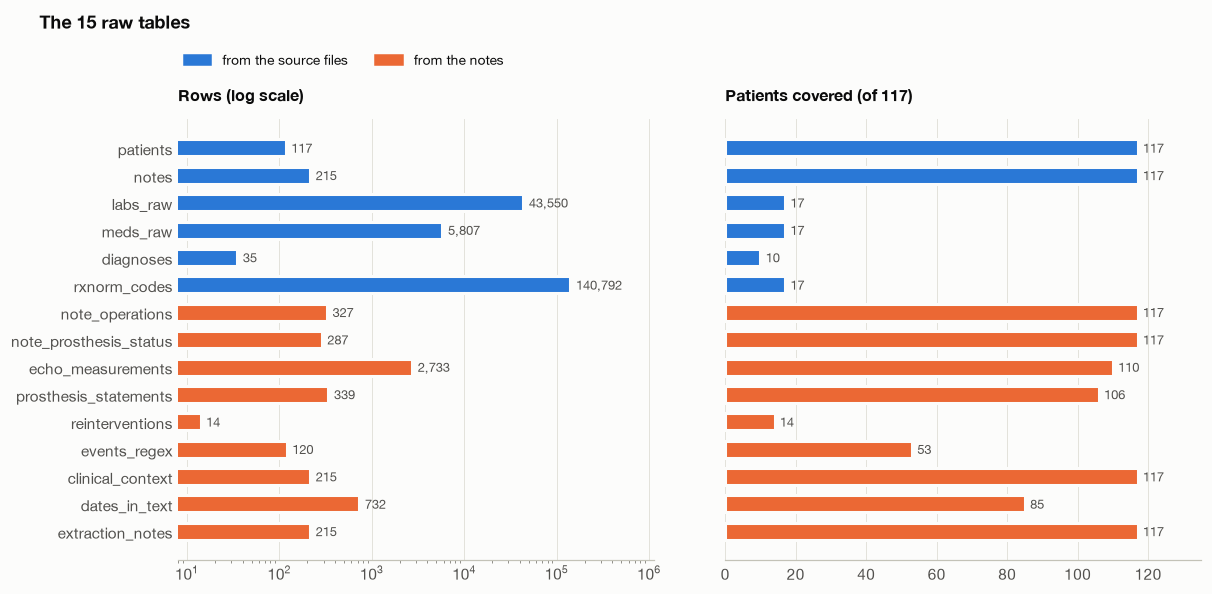

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, gridspec_kw=dict(wspace=0.15))
order = catalogue.index.tolist()
colors = [viz.SERIES[0] if g == "source files" else viz.SERIES[1] for g in catalogue.group]
y = np.arange(len(order))
axes[0].barh(y, catalogue.rows, height=0.62, color=colors, edgecolor=viz.SURFACE, linewidth=2)
axes[0].set_xscale("log")
axes[0].set_title("Rows (log scale)", fontsize=10.5)
for i, v in enumerate(catalogue.rows):
    axes[0].text(v * 1.15, i, f"{v:,}", va="center", fontsize=8.5, color=viz.INK_SECONDARY)
axes[0].set_xlim(8, catalogue.rows.max() * 8)
axes[1].barh(y, catalogue.patients, height=0.62, color=colors, edgecolor=viz.SURFACE, linewidth=2)
axes[1].set_title("Patients covered (of 117)", fontsize=10.5)
axes[1].set_xlim(0, 135)
for i, v in enumerate(catalogue.patients):
    axes[1].text(v + 1.5, i, f"{v}", va="center", fontsize=8.5, color=viz.INK_SECONDARY)
axes[0].set_yticks(y, order)
axes[0].invert_yaxis()
for ax in axes:
    ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=viz.SERIES[i]) for i in range(2)]
fig.legend(handles, ["from the source files", "from the notes"], loc="upper left", bbox_to_anchor=(0.12, 1.02), ncol=2, fontsize=9)
fig.suptitle("The 15 raw tables", x=0.02, y=1.07, ha="left", fontweight="bold")
viz.save(fig, "02_raw_tables")
plt.show()

### What the note extraction found

Echo values are the core of the endpoint, so this is the table that matters most. The model reading groups values into studies and labels each one as native or prosthetic valve and as before or after surgery; the rules reading has values only. Quoted statements about the prosthesis are the raw material for the event list the clinician adjudicates.

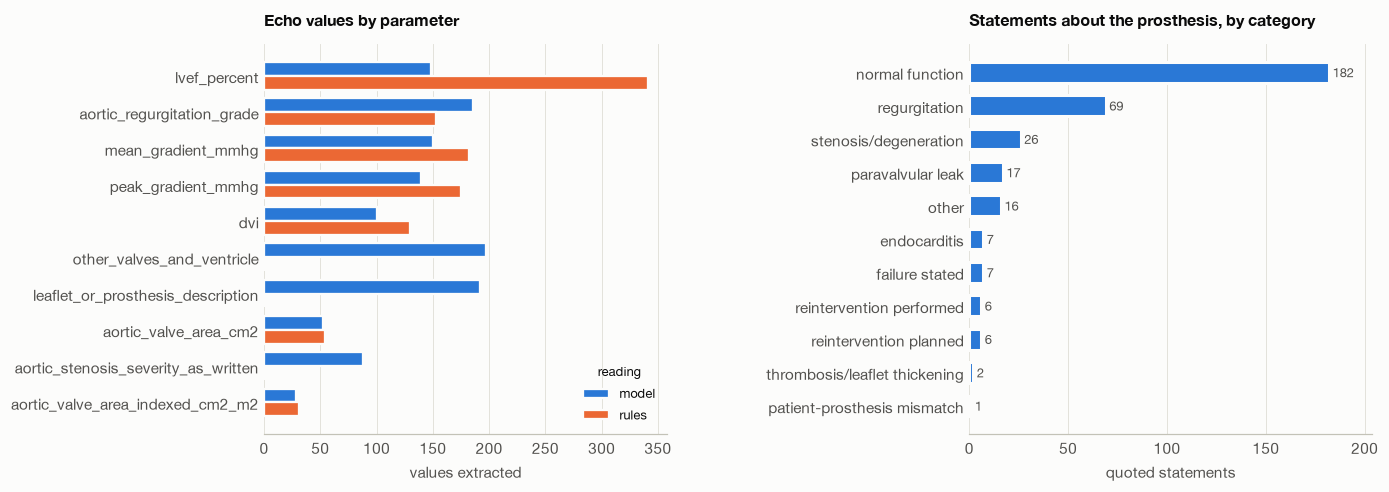

"timing (model reading, one row per echo study)",post-operative,pre-operative,unclear,total
valve assessed,,,,
native,0,94,0,94
prosthetic,193,13,0,206
unclear,11,5,6,22
total,204,112,6,322


In [4]:
E = raw["echo_measurements"].assign(reading=lambda d: short_method(d.method))
E = E[E.parameter != "study_recorded"]
top = E.parameter.value_counts().head(10).index
by = E[E.parameter.isin(top)].groupby(["parameter", "reading"]).size().unstack(fill_value=0).reindex(top)
S = raw["prosthesis_statements"].category.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(wspace=0.75))
y = np.arange(len(by))
h = 0.38
for i, col in enumerate(["model", "rules"]):
    axes[0].barh(y + (i - 0.5) * h, by[col], height=h, color=viz.SERIES[i], edgecolor=viz.SURFACE, linewidth=1.5, label=col)
axes[0].set_yticks(y, by.index)
axes[0].invert_yaxis()
axes[0].grid(axis="y", visible=False)
axes[0].legend(title="reading", fontsize=8.5, title_fontsize=8.5)
axes[0].set_title("Echo values by parameter", fontsize=10.5)
axes[0].set_xlabel("values extracted")
viz.hbar(axes[1], list(S.index), list(S.values), xlabel="quoted statements")
axes[1].set_title("Statements about the prosthesis, by category", fontsize=10.5)
viz.save(fig, "02_note_extraction")
plt.show()

m = raw["echo_measurements"]
m = m[short_method(m.method) == "model"].drop_duplicates(["note_id", "study_index"])
pd.crosstab(m.valve_assessed.fillna("not stated"), m.timing.fillna("not stated"), margins=True, margins_name="total").rename_axis(index="valve assessed", columns="timing (model reading, one row per echo study)")

### Column guide

`column_guide(name)` lists every column of a raw table with its type, how often it is filled and how many distinct values it has. Use it before writing a step that touches a table.

In [5]:
def column_guide(name):
    d = raw[name]
    return pd.DataFrame({
        "type": d.dtypes.astype(str),
        "filled": d.notna().mean().map("{:.0%}".format),
        "distinct values": d.nunique(),
    }).rename_axis(f"{name} column")

column_guide("echo_measurements")

,type,filled,distinct values
echo_measurements column,,,
note_id,str,100%,178
patient,str,100%,110
service_year,int64,100%,19
method,str,100%,2
study_index,float64,61%,9
study_label,str,61%,219
date_as_written,str,30%,21
timing,str,61%,3
valve_assessed,str,88%,4


In [6]:
patients = raw["patients"]
notes = raw["notes"]
note_operations = raw["note_operations"]
note_prosthesis_status = raw["note_prosthesis_status"]
echo_measurements = raw["echo_measurements"]
prosthesis_statements = raw["prosthesis_statements"]
reinterventions = raw["reinterventions"]
events_regex = raw["events_regex"]
clinical_context = raw["clinical_context"]
dates_in_text = raw["dates_in_text"]
extraction_notes = raw["extraction_notes"]
labs_raw = raw["labs_raw"]
meds_raw = raw["meds_raw"]
diagnoses = raw["diagnoses"]
rxnorm_codes = raw["rxnorm_codes"]

## 1. Remove exact duplicate rows

Input: `labs_raw`, `meds_raw`. The duplicate flag was computed on every source column.

Decision: drop rows where `is_exact_duplicate` is true. Nothing else changes.

Check: 19,002 lab rows and 2,157 medication rows remain.

In [7]:
def dedupe(df):
    ...


labs = dedupe(labs_raw)
meds = dedupe(meds_raw)

## 2. Separate lab results from everything else in the labs file

The labs file also holds respiratory therapy text, pacemaker and ICD interrogation, ECG intervals, blood bank and pathology.

Decision: an explicit list of component names that count as laboratory analytes. LOINC is present on a third of rows and cannot be the rule.

Output: `lab_results` (analytes only) and `lab_other` (the rest, kept for reference).

Check: no `Transcription`, `Lead Impedance` or `Work of Breathing` rows in `lab_results`.

In [8]:
ANALYTE_COMPONENTS = []


def split_labs(df):
    ...


lab_results, lab_other = None, None

## 3. Map analyte names and units

The same analyte appears under several component names and unit spellings (creatinine as `MG/DL` and `mg/dL`, four eGFR variants, two haemoglobin names).

Decision: a dictionary from component name to canonical analyte; units compared after lower-casing and removing spaces; censored values kept with `is_censored` and `censor_direction`.

Output: `lab_clean` with columns patient, year, analyte, value, unit, is_censored.

In [9]:
ANALYTE_MAP = {}


def map_analytes(df):
    ...


lab_clean = None

## 4. One implant record per patient

Input: `note_operations`, `note_prosthesis_status`, `notes`, `meds` (for the anaesthetic year of the 17 patients with no operative report).

Decisions to write here: which note is the index operation when a patient has several; how to treat a deleted operative report that has a signed twin; which reading wins when the rules and the model disagree (default: the model, and log the conflict); the most specific valve name across all the patient's notes; model level (exact, family, inferred, unknown).

Output: `implants`, 117 rows, one per patient, a provenance column beside each field.

Check: every patient has an approach or an explicit unknown; no patient has two index operations.

In [10]:
def build_implants(note_operations, note_prosthesis_status, notes, meds):
    ...


implants = None
conflicts = []

## 5. Echo timeline per patient

Input: `echo_measurements`, model rows only, pivoted to one row per study.

Decisions: keep studies where `valve_assessed` is prosthetic; drop a study that appears in two notes with identical numbers; order by note year, then by any date written in the text; the reference echo is the first prosthetic study in the implant year or the year after.

Output: `echo_timeline`, one row per study, with a sequence number within the patient and a flag for the reference echo.

Check: every study belongs to a patient with an implant record; no patient has two reference echoes.

In [11]:
def build_echo_timeline(echo_measurements, implants):
    ...


echo_timeline = None

## 6. Event table

Input: `reinterventions`, `prosthesis_statements`, `events_regex`.

One candidate row per event with type, year, reason as written and the quoted sentence. Two columns are left empty for the clinicians: structural deterioration yes or no, and VARC-3 category. Their answers come back as a small CSV that this cell reads; until it exists, a provisional rule fills the columns and marks the row as provisional.

Output: `events`.

In [12]:
ADJUDICATION_CSV = ROOT / "data" / "event_adjudication.csv"


def build_events(reinterventions, prosthesis_statements, events_regex):
    ...


events = None

## 7. Medication exposure by patient and year

Input: `meds`.

Flags per patient-year for anticoagulant, antiplatelet, statin, loop diuretic, RAAS inhibitor, SGLT2 inhibitor, and the anaesthetic marker used for the operation year. Inpatient and outpatient orders stay separate.

Output: `med_exposure`.

In [13]:
MED_CLASSES = {}


def build_med_exposure(meds):
    ...


med_exposure = None

## 8. Patient covariates

Input: `clinical_context`, `implants`.

Sex and comorbidities collapsed across a patient's notes (a yes in any note beats not stated), native valve morphology, concomitant CABG. Age is absent in the extract and stays absent; the column exists so the landmark table has the same shape as it would with real data.

Output: `covariates`, one row per patient.

In [14]:
def build_covariates(clinical_context, implants):
    ...


covariates = None

## 9. Landmark dataset

One row per patient per landmark. Landmarks are every prosthetic echo year plus fixed years 1, 3 and 5 after the reference echo, for patients still at risk.

Features are computed from rows dated at or before the landmark year: latest gradient, DVI, regurgitation grade and LVEF; change from the reference echo; slope over the last two studies; number of echoes so far; time since implant; latest labs; medication flags; covariates.

Outcome per row: what happened in the following 2 and 5 years (event, competing death, censored). Death is not in the extract, so the competing column is empty until vital status is obtained.

The split column is the implant year, so validation is temporal.

Output: `landmark` written to `data/landmark.parquet`.

In [15]:
HORIZONS = (2, 5)
FIXED_LANDMARKS = (1, 3, 5)


def build_landmark(implants, echo_timeline, events, lab_clean, med_exposure, covariates):
    ...


landmark = None

## 10. Coverage report

Prints, for the landmark table: rows and patients, non-missing share per feature, event counts per horizon, and the conflicts logged in step 4. The statement in the protocol about what this extract supports comes from this cell.

In [16]:
def coverage_report(landmark, conflicts):
    ...
